## phase 4

In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیم لاگ برای دیدن پیام‌ها در نوت‌بوک
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)


In [2]:
# Cell 2: paths and constants

# فایل فیچرهایی که در فاز ۲ ساختی
FEATURE_CSV_PATH = Path("feature2.csv")

# مدل‌های ذخیره شده در فاز ۳
svm_model_path = Path("svm_phase3.pkl")
dt_model_path = Path("dt_phase3.pkl")

TEST_SIZE = 0.2
RANDOM_STATE = 42  # حتماً با فاز ۳ یکسان باشد


In [3]:
# Cell 3: load features CSV and build X, y, train/test split

logging.info("Loading features from %s", FEATURE_CSV_PATH.resolve())
df = pd.read_csv(FEATURE_CSV_PATH)

# فرض بر این است که ساختار CSV این بوده:
# [filename, class_name, label_idx, feat_0, feat_1, ...]
# یعنی:
# ستون 0: نام فایل
# ستون 1: نام کلاس (متنی)
# ستون 2: label_idx (عددی)
# بقیه ستون‌ها: فیچرها

# ستون لیبل‌ها (label_idx)
y = df.iloc[:, 2].astype(int).values

# ستون‌های فیچر
X = df.iloc[:, 3:].astype("float32").values

logging.info("Feature matrix shape: %s", X.shape)
logging.info("Labels shape: %s", y.shape)

# ساخت mapping لیبل به نام کلاس از روی فایل (robust نسبت به ترتیب)
label_indices = df.iloc[:, 2].astype(int).values
class_names_col = df.iloc[:, 1].astype(str).values

label_to_name = {}
for lbl, name in zip(label_indices, class_names_col):
    label_to_name[int(lbl)] = name

num_classes = len(set(label_to_name.keys()))
target_names = [label_to_name[i] for i in range(num_classes)]

logging.info("Detected %d classes.", num_classes)
logging.info("Label -> class name mapping: %s", label_to_name)

# Train/test split (همان چیزی که در فاز ۳ انجام دادی)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

logging.info("X_train: %s, X_test: %s", X_train.shape, X_test.shape)
logging.info("y_train: %s, y_test: %s", y_train.shape, y_test.shape)


2025-12-03 21:57:24,300 [INFO] Loading features from E:\university\ML- fazl\project2\feature2.csv
2025-12-03 21:57:24,402 [INFO] Feature matrix shape: (26179, 37)
2025-12-03 21:57:24,402 [INFO] Labels shape: (26179,)
2025-12-03 21:57:24,408 [INFO] Detected 10 classes.
2025-12-03 21:57:24,408 [INFO] Label -> class name mapping: {0: 'butterfly', 1: 'cat', 2: 'chicken', 3: 'cow', 4: 'dog', 5: 'elephant', 6: 'horse', 7: 'sheep', 8: 'spider', 9: 'squirrel'}
2025-12-03 21:57:24,417 [INFO] X_train: (20943, 37), X_test: (5236, 37)
2025-12-03 21:57:24,417 [INFO] y_train: (20943,), y_test: (5236,)


In [4]:
# Cell 4: load tuned models from phase 3

logging.info("Loading tuned SVM model from %s", svm_model_path.resolve())
best_svm = joblib.load(svm_model_path)

logging.info("Loading tuned Decision Tree model from %s", dt_model_path.resolve())
best_dt = joblib.load(dt_model_path)

logging.info("Loaded models: SVM type=%s, DT type=%s", type(best_svm), type(best_dt))


2025-12-03 21:57:24,421 [INFO] Loading tuned SVM model from E:\university\ML- fazl\project2\svm_phase3.pkl
2025-12-03 21:57:24,452 [INFO] Loading tuned Decision Tree model from E:\university\ML- fazl\project2\dt_phase3.pkl
2025-12-03 21:57:24,481 [INFO] Loaded models: SVM type=<class 'sklearn.pipeline.Pipeline'>, DT type=<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [5]:
# Cell 5: define evaluation function

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, target_names=None):
    """
    مدل داده‌شده را روی train و test ارزیابی می‌کند و
    accuracy، precision_macro، recall_macro، f1_macro و ماتریس درهم‌ریختگی را برمی‌گرداند.
    """
    logging.info("======================================")
    logging.info("Evaluating model: %s", model_name)

    # پیش‌بینی روی train و test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {}

    for split_name, y_true, y_pred in [
        ("train", y_train, y_train_pred),
        ("test", y_test, y_test_pred),
    ]:
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        logging.info(
            "[%s][%s] accuracy: %.4f | precision_macro: %.4f | recall_macro: %.4f | f1_macro: %.4f",
            model_name,
            split_name,
            acc,
            prec,
            rec,
            f1,
        )

        # گزارش کامل per-class
        report = classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            digits=4,
            zero_division=0,
        )

        print(f"\n==== {model_name} - {split_name} classification report ====\n")
        print(report)

        metrics[split_name] = {
            "accuracy": acc,
            "precision_macro": prec,
            "recall_macro": rec,
            "f1_macro": f1,
            "confusion_matrix": cm,
            "classification_report": report,
        }

    return metrics


In [6]:
# Cell 6: run evaluation for both models

svm_metrics = evaluate_model(
    best_svm,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="SVM",
    target_names=target_names,
)

dt_metrics = evaluate_model(
    best_dt,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="DecisionTree",
    target_names=target_names,
)

# برای راحتی، می‌توانیم یک خلاصه عددی هم نشان دهیم
summary_rows = []
for model_name, m in [("SVM", svm_metrics), ("DecisionTree", dt_metrics)]:
    for split_name in ["train", "test"]:
        row = {
            "model": model_name,
            "split": split_name,
            "accuracy": m[split_name]["accuracy"],
            "precision_macro": m[split_name]["precision_macro"],
            "recall_macro": m[split_name]["recall_macro"],
            "f1_macro": m[split_name]["f1_macro"],
        }
        summary_rows.append(row)

metrics_df = pd.DataFrame(summary_rows)
metrics_df


2025-12-03 21:57:24,494 [INFO] ======================================
2025-12-03 21:57:24,497 [INFO] Evaluating model: SVM
C:\Users\ROG STRIX G614\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ROG STRIX G614\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
2025-12-03 21:58:02,063 [INFO] [SVM][train] accuracy: 0.5887 | precision_macro: 0.6119 | recall_macro: 0.5228 | f1_macro: 0.5454
2025-12-03 21:58:02,078 [INFO] [SVM][test] accuracy: 0.5015 | precision_macro: 0.4961 | recall_macro: 0.4339 | f1_macro: 0.4466
2025-12-03 21:58:02,080 


==== SVM - train classification report ====

              precision    recall  f1-score   support

   butterfly     0.8054    0.7544    0.7791      1690
         cat     0.7412    0.3478    0.4735      1334
     chicken     0.5449    0.6291    0.5840      2478
         cow     0.4987    0.3979    0.4426      1493
         dog     0.4838    0.7234    0.5798      3890
    elephant     0.6813    0.3898    0.4959      1157
       horse     0.4776    0.5329    0.5037      2098
       sheep     0.5711    0.3613    0.4426      1456
      spider     0.7384    0.8037    0.7697      3857
    squirrel     0.5760    0.2872    0.3833      1490

    accuracy                         0.5887     20943
   macro avg     0.6119    0.5228    0.5454     20943
weighted avg     0.6043    0.5887    0.5790     20943


==== SVM - test classification report ====

              precision    recall  f1-score   support

   butterfly     0.6863    0.6896    0.6879       422
         cat     0.5764    0.2485    0.34

,model,split,accuracy,precision_macro,recall_macro,f1_macro
0,SVM,train,0.588693,0.611851,0.522759,0.545420
1,SVM,test,0.501528,0.496072,0.433880,0.446629
2,DecisionTree,train,0.449267,0.482688,0.388070,0.401429
3,DecisionTree,test,0.360390,0.354223,0.305992,0.307778


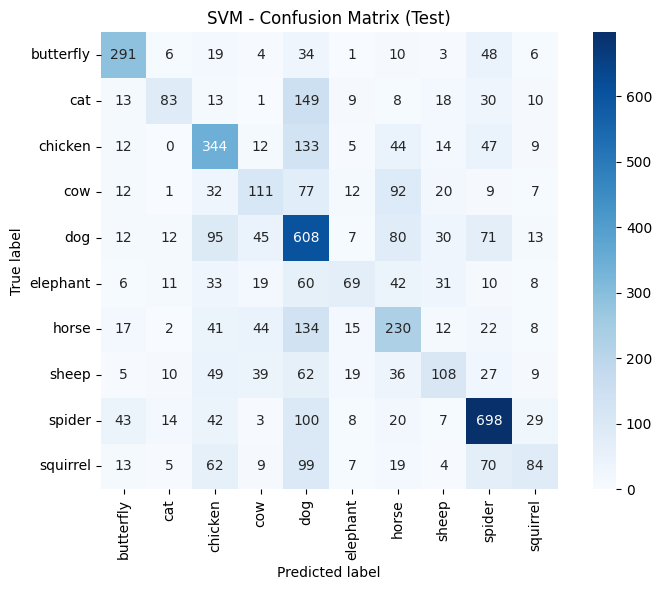

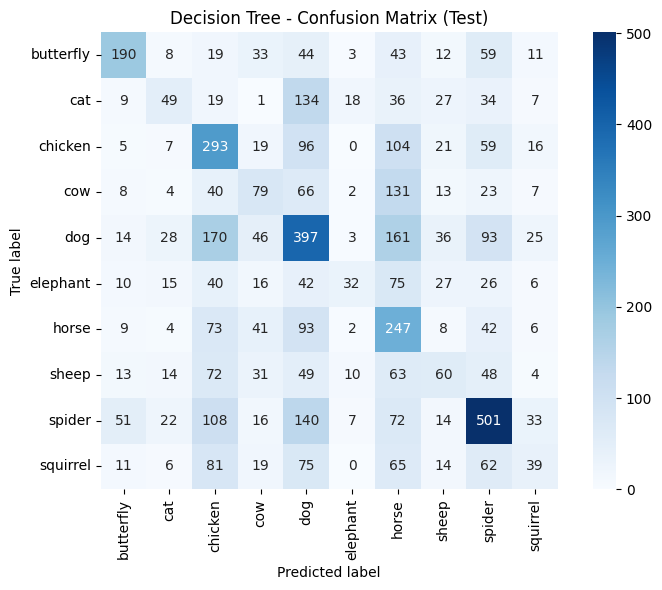

In [7]:
# Cell 7: confusion matrices visualization (test set)

def plot_confusion_matrix(cm, class_labels, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cmap="Blues",
        cbar=True,
        square=True,
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ماتریس درهم‌ریختگی روی تست
cm_svm_test = svm_metrics["test"]["confusion_matrix"]
cm_dt_test = dt_metrics["test"]["confusion_matrix"]

plot_confusion_matrix(cm_svm_test, target_names, "SVM - Confusion Matrix (Test)")
plot_confusion_matrix(cm_dt_test, target_names, "Decision Tree - Confusion Matrix (Test)")


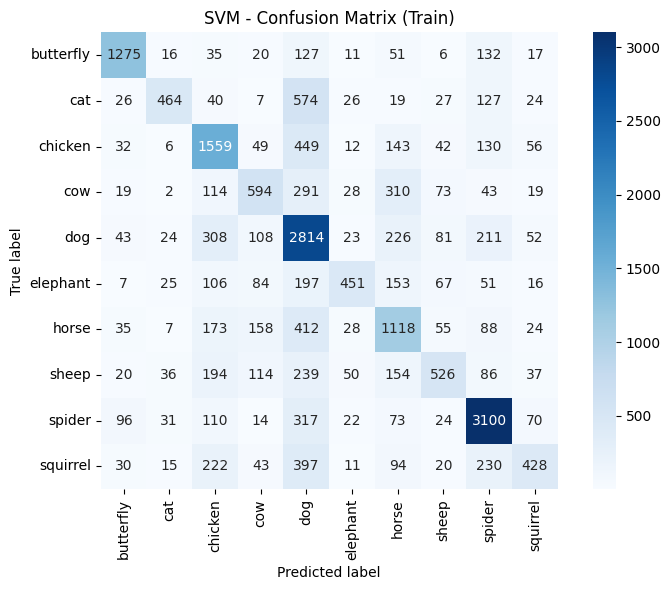

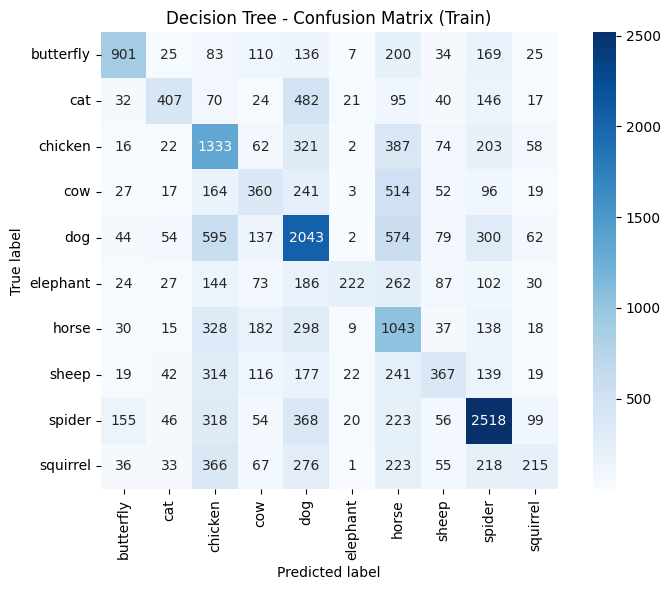

In [8]:
# Cell 7b (اختیاری): confusion matrices for train set

cm_svm_train = svm_metrics["train"]["confusion_matrix"]
cm_dt_train = dt_metrics["train"]["confusion_matrix"]

plot_confusion_matrix(cm_svm_train, target_names, "SVM - Confusion Matrix (Train)")
plot_confusion_matrix(cm_dt_train, target_names, "Decision Tree - Confusion Matrix (Train)")


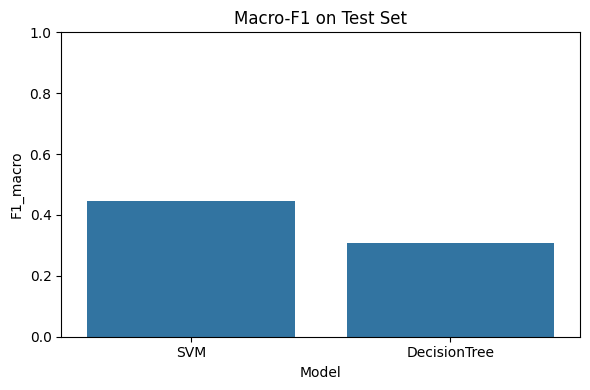

In [9]:
# Cell 8: bar plot comparison of macro-F1 on test set

test_df = metrics_df[metrics_df["split"] == "test"].copy()

plt.figure(figsize=(6, 4))
sns.barplot(
    data=test_df,
    x="model",
    y="f1_macro",
)
plt.title("Macro-F1 on Test Set")
plt.ylabel("F1_macro")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
